In [1]:
import pandas as pd

In [2]:
df=pd.read_excel("C:/Users/stali/Documents/proyecto_machine_learning/clasificador_reclamos_requerimientos/data/BD.xlsx",sheet_name="BD")

In [3]:
df['flg_oot']=df.apply(lambda x: 1 if x['FINAL']=='RECLAMO' and x['ANIO']==2023
                                   else 1 if x['FINAL']=='REQUERIMIENTO' and x['MESANIO']==202304
                                   else 0, axis=1)

In [4]:
df_oot=df[df['flg_oot']==1]

## Estandarizar comentarios

In [5]:
display(df_oot.head())

,SOURCE,ANIO,MESANIO,COMENTARIO,FINAL,ALEATORIO,flg_oot
7,ATENCION EN PLATAFORMA,2023,202304,"Se informa que, las citas médicas debe separar...",REQUERIMIENTO,0.999536,1
13,ATENCION EN PLATAFORMA,2023,202304,Asegurada informa se atendió en CSB le negaron...,REQUERIMIENTO,0.999400,1
16,ATENCION EN PLATAFORMA,2023,202304,Se deriva a MAD para Requerimientos pendientes,REQUERIMIENTO,0.998914,1
18,ATENCION EN PLATAFORMA,2023,202304,ATENCION SIN SITED_CUENCA CABANILLAS ALBERTO J...,REQUERIMIENTO,0.998833,1
44,RECLAMOS,2023,202301,"yo, Alexander Medina Troncoso, con DNI 1069719...",RECLAMO,0.998056,1


In [6]:
import sys
sys.path.append('../scr')
from funciones import limpiar_comentario

In [7]:
df_oot['COMENTARIO_limpio']=df_oot['COMENTARIO'].apply(limpiar_comentario)

In [8]:
#display(df_oot.head())

In [9]:
#quitar stop words

In [10]:
stop_words = {
    #detectados segun ranking
    'la','el','lo','al','los','las','le','ella',
   'de', 'se','que','en','por','su','del','una','ya','es'
    ,'dia','fecha','si','esta',
    'con','para',
    'ha',
    'un',
    #añadidos por sugerencia de ia
    'asegurado','asegurada',

    'mi', 'mis', 'me', 'nos', 'te', 'le', 'les', 'yo', 'usted', 'ustedes', 'este', 'esta', 'estos', 'esta','a'
}

In [11]:
import nltk

In [12]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\stali\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [13]:
#funcion para cada stop_words(para cada comentario)
from funciones import quitar_stop_words

In [14]:
df_oot['COMENTARIO_limpio_sin_stopwords']=df_oot['COMENTARIO_limpio'].apply(lambda x: quitar_stop_words(x,stop_words))

In [15]:
display(df_oot.head())

,SOURCE,ANIO,MESANIO,COMENTARIO,FINAL,ALEATORIO,flg_oot,COMENTARIO_limpio,COMENTARIO_limpio_sin_stopwords
7,ATENCION EN PLATAFORMA,2023,202304,"Se informa que, las citas médicas debe separar...",REQUERIMIENTO,0.999536,1,se informa que las citas medicas debe separarl...,informa citas medicas debe separarlas directam...
13,ATENCION EN PLATAFORMA,2023,202304,Asegurada informa se atendió en CSB le negaron...,REQUERIMIENTO,0.999400,1,asegurada informa se atendio en csb le negaron...,informa atendio csb negaron examenes mutacion ...
16,ATENCION EN PLATAFORMA,2023,202304,Se deriva a MAD para Requerimientos pendientes,REQUERIMIENTO,0.998914,1,se deriva a mad para requerimientos pendientes,deriva mad requerimientos pendientes
18,ATENCION EN PLATAFORMA,2023,202304,ATENCION SIN SITED_CUENCA CABANILLAS ALBERTO J...,REQUERIMIENTO,0.998833,1,atencion sin sitedcuenca cabanillas alberto ju...,atencion sin sitedcuenca cabanillas alberto ju...
44,RECLAMOS,2023,202301,"yo, Alexander Medina Troncoso, con DNI 1069719...",RECLAMO,0.998056,1,yo alexander medina troncoso con dni me atendi...,alexander medina troncoso dni atendi emergenci...


## Vectorizar TF IDF

In [16]:
import joblib

In [17]:
modelo_tf_idf_oot=joblib.load('C:/Users/stali/Documents/proyecto_machine_learning/clasificador_reclamos_requerimientos/modelos/tf_idf_model.pkl')

In [18]:
X_oot_tf_idf=modelo_tf_idf_oot.transform(df_oot['COMENTARIO_limpio_sin_stopwords'])

## Predecir con RegrLog

In [19]:
modelo_reg_log=joblib.load('C:/Users/stali/Documents/proyecto_machine_learning/clasificador_reclamos_requerimientos/modelos/reg_log_model.pkl')

In [20]:
Y_predict=modelo_reg_log.predict(X_oot_tf_idf)
Y_predict_proba=modelo_reg_log.predict_proba(X_oot_tf_idf)

## Validaciones

In [21]:
from sklearn.metrics import (accuracy_score, precision_score, confusion_matrix, recall_score,f1_score)

In [22]:
accuracy=accuracy_score(df_oot['FINAL'],Y_predict)
precision=precision_score(df_oot['FINAL'],Y_predict,average='weighted')
recall=recall_score(df_oot['FINAL'],Y_predict,average='weighted')
f1=f1_score(df_oot['FINAL'],Y_predict,average='weighted')

print(f'el accuracy es: {accuracy}')
print(f'la precision es: {precision}')
print(f'el recall es: {recall}')
print(f'el f1 es: {f1}')

el accuracy es: 0.983554376657825
la precision es: 0.9835600074585196
el recall es: 0.983554376657825
el f1 es: 0.9835568947100314


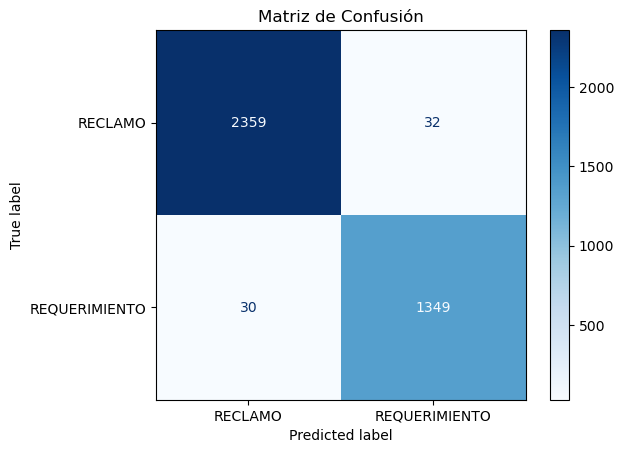

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    df_oot['FINAL'],
    Y_predict,
    cmap="Blues"
)

plt.title("Matriz de Confusión")
plt.show()

In [24]:
#exportar resultados
df_resultados_oot=pd.DataFrame({
    #'Comentario_real':,
    'Comentario_limpio':df_oot['COMENTARIO_limpio_sin_stopwords'],
    'Clasificion_real':df_oot['FINAL'],
    'Prediccion':Y_predict,
    'Prob_reclamo':Y_predict_proba[:,0],
    'Prob_requerimiento':Y_predict_proba[:,1],
    'Prob_prediccion':Y_predict_proba.max(axis=1)
}
)

In [25]:
df_resultados_oot['flg_prediccion']=df_resultados_oot.apply(lambda x:
                                                              1 if x['Prediccion']==x['Clasificion_real']
                                                                       else 0, axis=1)

In [26]:
#quedarnos con un rango que sea seguro pero confiable: df_resultados_test
total_oot=len(df_resultados_oot)
rangos=[0.95, 0.90, 0.85, 0.80, 0.7, 0.6, 0.55,0.51]
accuracy_rangos=[]
cantidad_rangos=[]
no_cubiertos=[]
porc_no_cubiertos=[]
for umbral in rangos:
    df_umbral=df_resultados_oot[df_resultados_oot['Prob_prediccion']>=umbral]
    accuracy=df_umbral['flg_prediccion'].mean()
    accuracy_rangos.append(accuracy)
    cantidad_rangos.append(len(df_umbral))
    no_cubiertos.append(total_oot-len(df_umbral))
    porc_no_cubiertos.append((total_oot-len(df_umbral))/total_oot)
    
resumen_umbrales=pd.DataFrame({
    'umbral': rangos,
    "Casos cubiertos": cantidad_rangos,
    "Casos No Cubiertos": no_cubiertos,
    "Porcentaje No Cubiertos":porc_no_cubiertos,
    'accuracy':accuracy_rangos
})

display(resumen_umbrales)

,umbral,Casos cubiertos,Casos No Cubiertos,Porcentaje No Cubiertos,accuracy
0,0.95,2003,1767,0.468700,1.000000
1,0.90,2775,995,0.263926,0.999640
2,0.85,3169,601,0.159416,0.999053
3,0.80,3373,397,0.105305,0.998814
4,0.70,3576,194,0.051459,0.997763
5,0.60,3685,85,0.022546,0.992673
6,0.55,3723,47,0.012467,0.988719
7,0.51,3757,13,0.003448,0.985627
